# notebook 3 · avocado prices
## zero-shot foundation model vs classical baselines

**dataset** · weekly retail price of conventional avocados — TotalUS aggregate · 2015–2018
**source** · kaggle `neuromusic/avocado-prices`
**test horizon** · 12 weeks (3 months)
**models** · seasonal naive · sarima · ets holt-winters · chronos-t5-tiny (zero-shot)

This dataset is closer to the **agricultural-prices** setting mentioned in the motivating paper. Avocado prices are noisier and less regular than air passengers or energy — the kind of datawhere foundation models are supposed to be best over classical baselines.

In [37]:
# standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams.update({'figure.figsize': (13, 5), 'axes.grid': True, 'grid.alpha': 0.3})

In [38]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("neuromusic/avocado-prices")

print("Path to dataset files:", path)

csv_file = os.path.join(path, 'avocado.csv')

100%|██████████| 629k/629k [00:00<00:00, 72.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/neuromusic/avocado-prices/versions/1


In [39]:
# load and filter: conventional avocados, total us market
df = pd.read_csv(csv_file, parse_dates=['Date'])

mask = (df['type'] == 'conventional') & (df['region'] == 'TotalUS')
us = df[mask].sort_values('Date').set_index('Date')

# weekly average price
series = us['AveragePrice'].resample('W').mean().rename('avg_price_usd')
series = series.dropna()

print(f"observations : {len(series)}")
print(f"range        : {series.index[0].date()} → {series.index[-1].date()}")
print(f"mean price   : ${series.mean():.2f}")
series.tail()

observations : 169
range        : 2015-01-04 → 2018-03-25
mean price   : $1.09


,avg_price_usd
Date,
2018-02-25,1.06
2018-03-04,1.07
2018-03-11,1.09
2018-03-18,1.05
2018-03-25,1.03


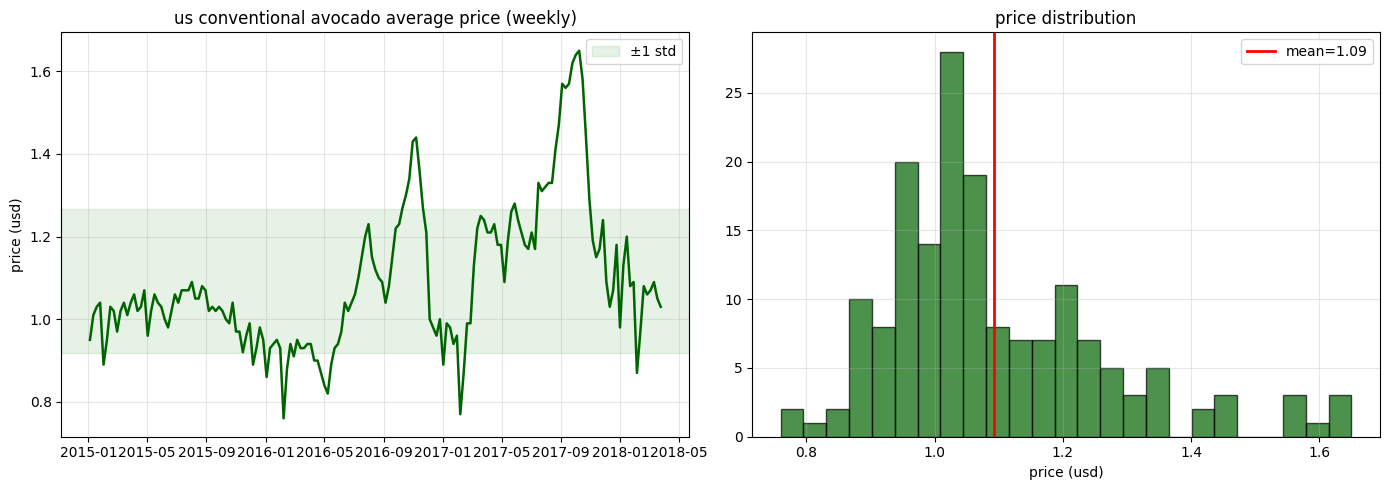

In [40]:
# exploratory plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# full price series
axes[0].plot(series, color='darkgreen', lw=1.8)
axes[0].set_title('us conventional avocado average price (weekly)')
axes[0].set_ylabel('price (usd)')
axes[0].axhspan(series.mean() - series.std(), series.mean() + series.std(),
                alpha=0.1, color='green', label='±1 std')
axes[0].legend()

# distribution
axes[1].hist(series, bins=25, color='darkgreen', alpha=0.7, edgecolor='k')
axes[1].axvline(series.mean(), color='red', lw=2, label=f'mean={series.mean():.2f}')
axes[1].set_title('price distribution')
axes[1].set_xlabel('price (usd)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'avocado_eda.png', dpi=100, bbox_inches='tight')
plt.show()

In [41]:
# train/test split — last 12 weeks as test
HORIZON = 12
train = series[:-HORIZON]
test  = series[-HORIZON:]
print(f"train : {len(train)} obs  ({train.index[0].date()} → {train.index[-1].date()})")
print(f"test  : {len(test)} obs  ({test.index[0].date()}  → {test.index[-1].date()})")

train : 157 obs  (2015-01-04 → 2017-12-31)
test  : 12 obs  (2018-01-07  → 2018-03-25)


In [42]:
# model 1: seasonal naïve (period = 52 weeks)
m = 52
snaive = pd.Series(
    np.tile(train.values[-m:], int(np.ceil(HORIZON / m)))[:HORIZON],
    index=test.index
)
print("seasonal naive: ready")

seasonal naive: ready


In [43]:
# model 2: sarima(1,1,1)(1,1,1)52
sarima_fit = SARIMAX(train, order=(2,1,2), seasonal_order=(1,0,1,52)).fit(disp=False)
sarima = pd.Series(sarima_fit.forecast(HORIZON).values, index=test.index)
print(f"sarima aic: {sarima_fit.aic:.1f}")

sarima aic: -419.5


In [44]:
# model 3: ets holt-winters additive
ets_fit = ExponentialSmoothing(
    train, trend='add', seasonal='add', seasonal_periods=52
).fit()
ets = pd.Series(ets_fit.forecast(HORIZON).values, index=test.index)
print("ets: ready")

ets: ready


In [32]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'chronos-forecasting', '-q'],
               capture_output=True)

import torch
from chronos import ChronosPipeline

# load the smallest chronos model — runs on cpu
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-tiny",
    device_map="cpu",
    torch_dtype=torch.float32,
)


In [45]:
# model 4: chronos-t5-tiny (zero-shot)
ctx = torch.tensor(train.values, dtype=torch.float32).unsqueeze(0)

samples = pipeline.predict(ctx, prediction_length=HORIZON, num_samples=100)
s_np    = samples[0].numpy()

chronos_median = pd.Series(np.median(s_np, axis=0), index=test.index)
chronos_lo     = np.percentile(s_np, 10, axis=0)
chronos_hi     = np.percentile(s_np, 90, axis=0)
print("chronos-tiny zero-shot: ready")

chronos-tiny zero-shot: ready


In [46]:
# evaluation
def mape(y, yhat):
    return np.mean(np.abs((y - yhat) / y)) * 100

def rmse(y, yhat):
    return np.sqrt(mean_squared_error(y, yhat))

preds = {
    'seasonal_naive' : snaive,
    'sarima'         : sarima,
    'ets'            : ets,
    'chronos_tiny'   : chronos_median,
}

rows = [{
    'model'  : name,
    'MAE'    : round(mean_absolute_error(test, p), 4),
    'RMSE'   : round(rmse(test.values, p.values), 4),
    'MAPE_%' : round(mape(test.values, p.values), 2),
} for name, p in preds.items()]

metrics_df = pd.DataFrame(rows).set_index('model').sort_values('MAPE_%')
print(metrics_df)

                   MAE    RMSE  MAPE_%
model                                 
ets             0.0619  0.0728    5.76
sarima          0.0726  0.0897    6.65
chronos_tiny    0.0812  0.0991    7.82
seasonal_naive  0.1325  0.1420   12.44


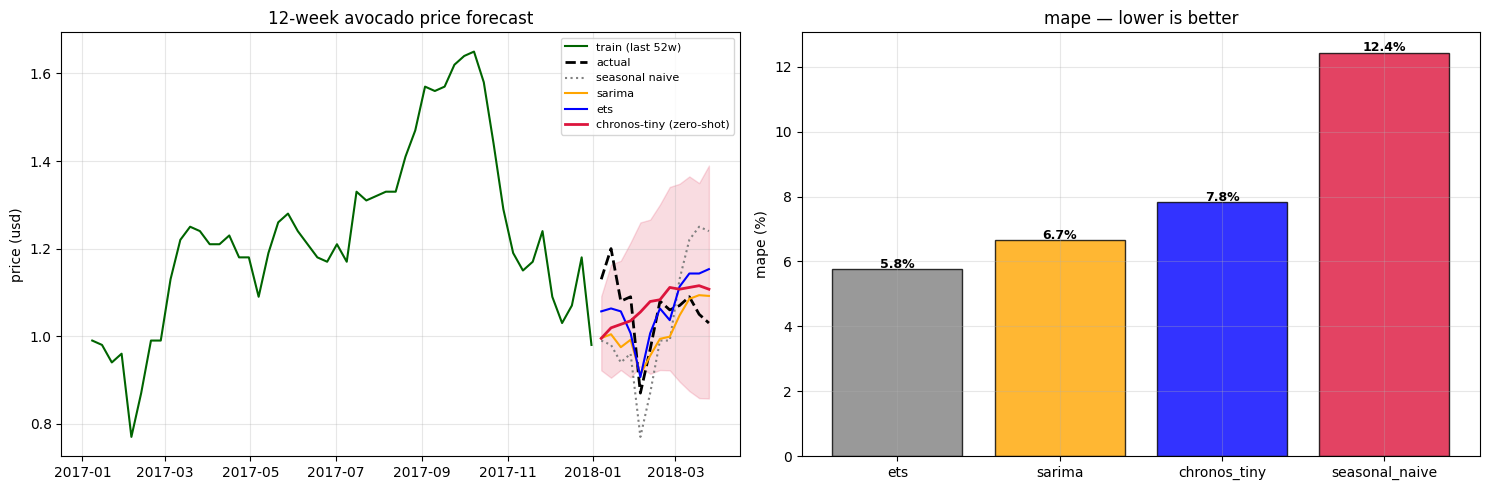

In [48]:
# forecast + bar chart plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(train.iloc[-52:], color='darkgreen', lw=1.5, label='train (last 52w)')
ax.plot(test,  color='black',  lw=2.0, ls='--', label='actual')
ax.plot(snaive,         color='gray',   lw=1.5, ls=':', label='seasonal naive')
ax.plot(sarima,         color='orange', lw=1.5, label='sarima')
ax.plot(ets,            color='blue',   lw=1.5, label='ets')
ax.plot(chronos_median, color='crimson',lw=2.0, label='chronos-tiny (zero-shot)')
ax.fill_between(test.index, chronos_lo, chronos_hi, color='crimson', alpha=0.15)
ax.set_title('12-week avocado price forecast')
ax.set_ylabel('price (usd)')
ax.legend(fontsize=8)

ax2 = axes[1]
colors = ['gray','orange','blue','crimson']
bars = ax2.bar(metrics_df.index, metrics_df['MAPE_%'], color=colors, alpha=0.8, edgecolor='k')
ax2.set_title('mape — lower is better')
ax2.set_ylabel('mape (%)')
for b, v in zip(bars, metrics_df['MAPE_%']):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height()+0.05, f'{v:.1f}%',
             ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'avocado_forecast.png', dpi=100, bbox_inches='tight')
plt.show()

## summary & insights

ETS wins at 5.76% - after the 2017 price spike, avocado prices dropped back to a stable $1.00 level, which is exactly the smooth continuation ETS handles well. SARIMA is close behind at 6.65%. Chronos comes 3rd at 7.82%. It beats seasonal naive comfortably (12.44%) but does not outperform the classical models here. Zero-shot generalization is competitive, not dominant. Seasonal naive fails because the last observed season (late 2017) was the spike peak - repeating it produces a forecast far above the actual prices.